DBSCAN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from collections import Counter

In [5]:
X_scaled = pd.read_csv('single_variable_data.csv')

In [6]:
def find_optimal_eps(X, min_samples_range=[3, 5, 7, 10]):
    """
    k-distance graph를 그려서 적정 eps 값을 시각적으로 찾기
    """
    fig, axes = plt.subplots(1, len(min_samples_range), figsize=(15, 4))
    
    for idx, min_samples in enumerate(min_samples_range):
        # k번째 이웃까지의 거리 계산 (k = min_samples - 1)
        neigh = NearestNeighbors(n_neighbors=min_samples)
        neigh.fit(X)
        distances, _ = neigh.kneighbors(X)
        
        # min_samples번째 이웃까지의 거리 (0-based index라서 min_samples-1)
        k_distances = np.sort(distances[:, min_samples-1])
        
        # 그래프 그리기
        axes[idx].plot(k_distances)
        axes[idx].set_xlabel('Data points sorted by distance')
        axes[idx].set_ylabel(f'{min_samples}-th nearest neighbor distance')
        axes[idx].set_title(f'k-distance graph (min_samples={min_samples})')
        axes[idx].grid(True, alpha=0.3)
        
        # 추천 eps 표시 (팔꿈치 지점 근처)
        # 그래프에서 급격히 꺾이는 지점 찾기
        gradients = np.diff(k_distances)
        elbow_idx = np.argmax(gradients[:len(gradients)//2])  # 앞부분에서 가장 가파른 지점
        recommended_eps = k_distances[elbow_idx]
        axes[idx].axhline(y=recommended_eps, color='r', linestyle='--', 
                         label=f'recommended eps={recommended_eps:.3f}')
        axes[idx].legend()
    
    plt.tight_layout()
    plt.show()

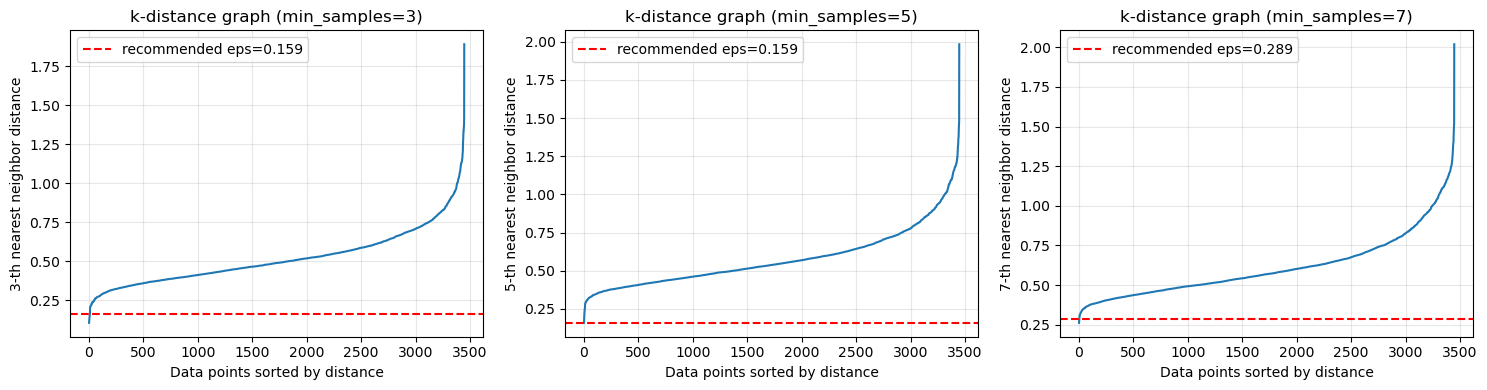

In [8]:
find_optimal_eps(X_scaled, min_samples_range=[3, 5, 7])

In [9]:
def evaluate_dbscan_parameters(X, eps_values, min_samples_values):
    """
    다양한 eps와 min_samples 조합을 평가하여 최적 파라미터 찾기
    """
    results = []
    
    for eps in eps_values:
        for min_samples in min_samples_values:
            # DBSCAN 실행
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            labels = dbscan.fit_predict(X)
            
            # 결과 분석
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)
            noise_ratio = n_noise / len(labels)
            
            # 실루엣 점수 (클러스터가 2개 이상이고 노이즈 제외)
            silhouette = -1
            if n_clusters >= 2:
                mask = labels != -1
                if len(set(labels[mask])) >= 2:
                    silhouette = silhouette_score(X[mask], labels[mask])
            
            results.append({
                'eps': eps,
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'noise_ratio': noise_ratio,
                'silhouette_score': silhouette
            })
    
    return pd.DataFrame(results)

In [10]:
# 파라미터 범위 설정 (k-distance graph 결과에 따라 조정)
eps_values = np.arange(0.3, 2.0, 0.1)  # 0.3 ~ 2.0, 0.1 간격
min_samples_values = [3, 5, 7, 10]

In [11]:
# 평가 실행
print("파라미터 평가 중...")
results_df = evaluate_dbscan_parameters(X_scaled, eps_values, min_samples_values)

파라미터 평가 중...


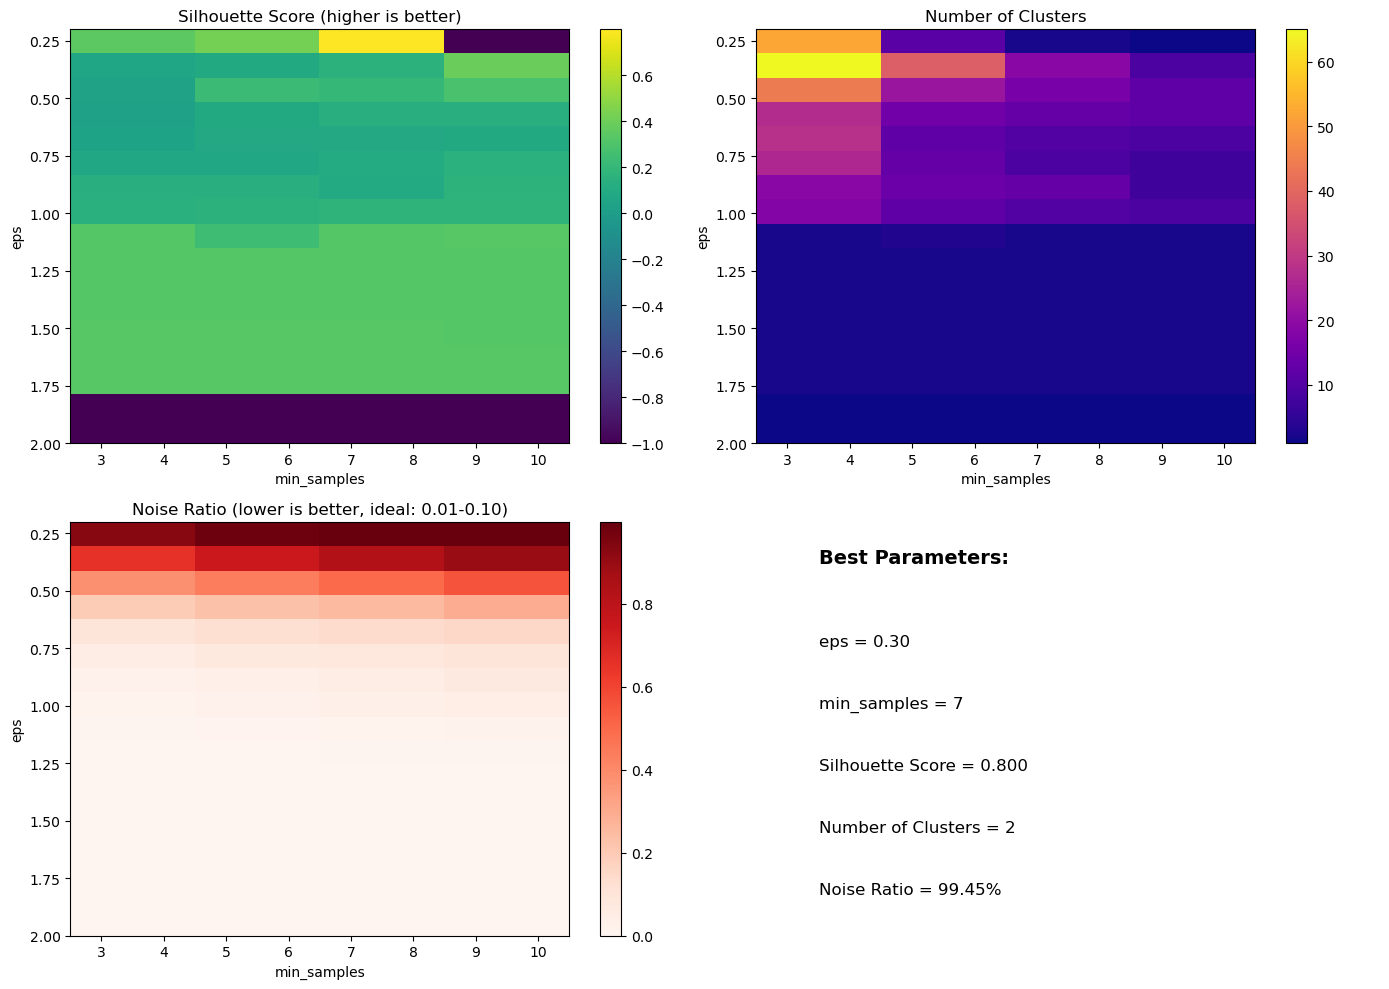

In [15]:
# ============================================
# 4. 결과 시각화
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 4-1) 실루엣 점수 히트맵
pivot_sil = results_df.pivot(index='eps', columns='min_samples', values='silhouette_score')
im1 = axes[0, 0].imshow(pivot_sil.values, aspect='auto', cmap='viridis', 
                        extent=[pivot_sil.columns[0]-0.5, pivot_sil.columns[-1]+0.5,
                               pivot_sil.index[-1]+0.1, pivot_sil.index[0]-0.1])
axes[0, 0].set_xlabel('min_samples')
axes[0, 0].set_ylabel('eps')
axes[0, 0].set_title('Silhouette Score (higher is better)')
plt.colorbar(im1, ax=axes[0, 0])

# 4-2) 클러스터 개수 히트맵
pivot_clusters = results_df.pivot(index='eps', columns='min_samples', values='n_clusters')
im2 = axes[0, 1].imshow(pivot_clusters.values, aspect='auto', cmap='plasma',
                        extent=[pivot_clusters.columns[0]-0.5, pivot_clusters.columns[-1]+0.5,
                               pivot_clusters.index[-1]+0.1, pivot_clusters.index[0]-0.1])
axes[0, 1].set_xlabel('min_samples')
axes[0, 1].set_ylabel('eps')
axes[0, 1].set_title('Number of Clusters')
plt.colorbar(im2, ax=axes[0, 1])

# 4-3) 노이즈 비율 히트맵
pivot_noise = results_df.pivot(index='eps', columns='min_samples', values='noise_ratio')
im3 = axes[1, 0].imshow(pivot_noise.values, aspect='auto', cmap='Reds',
                        extent=[pivot_noise.columns[0]-0.5, pivot_noise.columns[-1]+0.5,
                               pivot_noise.index[-1]+0.1, pivot_noise.index[0]-0.1])
axes[1, 0].set_xlabel('min_samples')
axes[1, 0].set_ylabel('eps')
axes[1, 0].set_title('Noise Ratio (lower is better, ideal: 0.01-0.10)')
plt.colorbar(im3, ax=axes[1, 0])

# 4-4) 최적 파라미터 하이라이트
# 실루엣 점수가 가장 높은 조합 찾기
best_idx = results_df['silhouette_score'].idxmax()
best_row = results_df.loc[best_idx]

axes[1, 1].axis('off')
axes[1, 1].text(0.1, 0.9, f"Best Parameters:", fontsize=14, fontweight='bold')
axes[1, 1].text(0.1, 0.7, f"eps = {best_row['eps']:.2f}", fontsize=12)
axes[1, 1].text(0.1, 0.55, f"min_samples = {int(best_row['min_samples'])}", fontsize=12)
axes[1, 1].text(0.1, 0.4, f"Silhouette Score = {best_row['silhouette_score']:.3f}", fontsize=12)
axes[1, 1].text(0.1, 0.25, f"Number of Clusters = {int(best_row['n_clusters'])}", fontsize=12)
axes[1, 1].text(0.1, 0.10, f"Noise Ratio = {best_row['noise_ratio']:.2%}", fontsize=12)

plt.tight_layout()
plt.show()

In [16]:
# ============================================
# 5. 최적 파라미터로 최종 DBSCAN 실행
# ============================================
print("\n" + "="*50)
print("최적 파라미터로 DBSCAN 실행")
print("="*50)

best_eps = best_row['eps']
best_min_samples = int(best_row['min_samples'])

dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
labels = dbscan.fit_predict(X_scaled)


최적 파라미터로 DBSCAN 실행


In [17]:
# 결과 분석
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
noise_ratio = n_noise / len(labels)

print(f"파라미터: eps={best_eps:.2f}, min_samples={best_min_samples}")
print(f"클러스터 개수: {n_clusters}")
print(f"노이즈 포인트: {n_noise}개 ({noise_ratio:.2%})")

파라미터: eps=0.30, min_samples=7
클러스터 개수: 2
노이즈 포인트: 3429개 (99.45%)


In [18]:
# 클러스터별 크기
cluster_counts = Counter(labels)
print("\n클러스터별 크기:")
for cluster_id, count in sorted(cluster_counts.items()):
    if cluster_id == -1:
        print(f"  Noise: {count}개 ({count/len(labels):.1%})")
    else:
        print(f"  Cluster {cluster_id}: {count}개 ({count/len(labels):.1%})")


클러스터별 크기:
  Noise: 3429개 (99.4%)
  Cluster 0: 12개 (0.3%)
  Cluster 1: 7개 (0.2%)


In [ ]:
# ============================================
# 6. 실루엣 점수 계산 (노이즈 제외)
# ============================================
if n_clusters >= 2:
    mask = labels != -1
    sil_score = silhouette_score(X_scaled[mask], labels[mask])
    print(f"\n실루엣 점수 (노이즈 제외): {sil_score:.3f}")
else:
    print(f"\n실루엣 점수: 클러스터가 2개 미만이어서 계산 불가")

In [ ]:
# DBSCAN 결과
unique_labels = set(labels)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    mask = labels == label
    if label == -1:
        axes[0].scatter(X_scaled[mask, 0], X_scaled[mask, 1], 
                       c='gray', s=20, alpha=0.5, label=f'Noise')
    else:
        axes[0].scatter(X_scaled[mask, 0], X_scaled[mask, 1], 
                       c=[color], s=30, alpha=0.7, label=f'Cluster {label}')

axes[0].set_xlabel('Feature 1 (scaled)')
axes[0].set_ylabel('Feature 2 (scaled)')
axes[0].set_title(f'DBSCAN Clustering (eps={best_eps:.2f}, min_samples={best_min_samples})')
axes[0].legend(loc='best', fontsize=8)
